<a href="https://colab.research.google.com/github/vidyasreedharan2003-a11y/ML-PROJECT/blob/main/day7(section_2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as ps
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [ ]:
df.dropna(subset=['bill_length_mm','flipper_length_mm'],inplace=True)

In [ ]:
df['sex']=df['sex'].fillna(df['sex'].mode()[0])

In [ ]:
df.isnull().sum()

,0
species,0
island,0
bill_length_mm,0
bill_depth_mm,0
flipper_length_mm,0
body_mass_g,0
sex,0


In [ ]:
from scipy.stats import skew
cat_value=df.select_dtypes(include=["object"]).columns
num_value=df.select_dtypes(include=["int64","float64"]).columns

skew_value=df[num_value].skew()
skew_value

,0
bill_length_mm,0.053118
bill_depth_mm,-0.143465
flipper_length_mm,0.345682
body_mass_g,0.470329


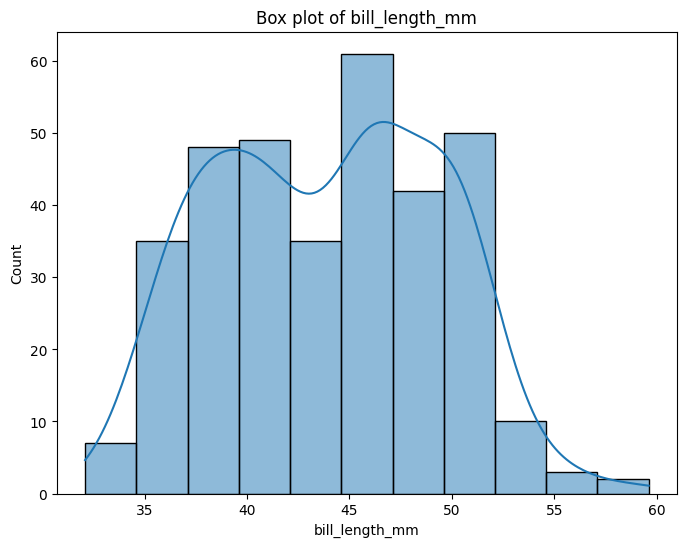

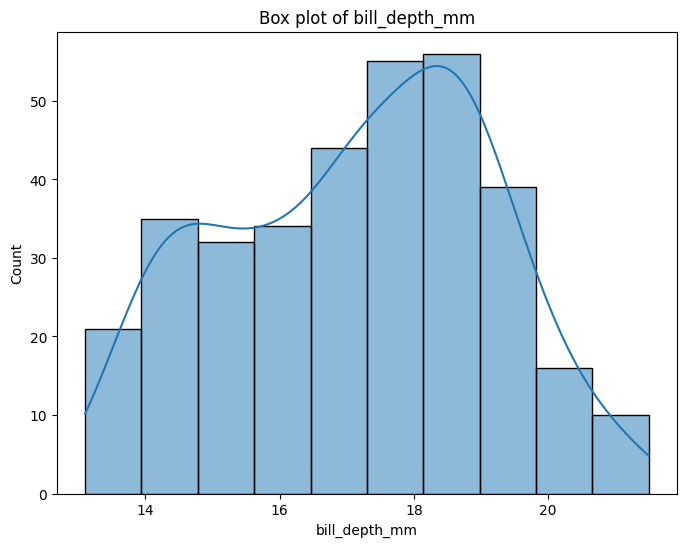

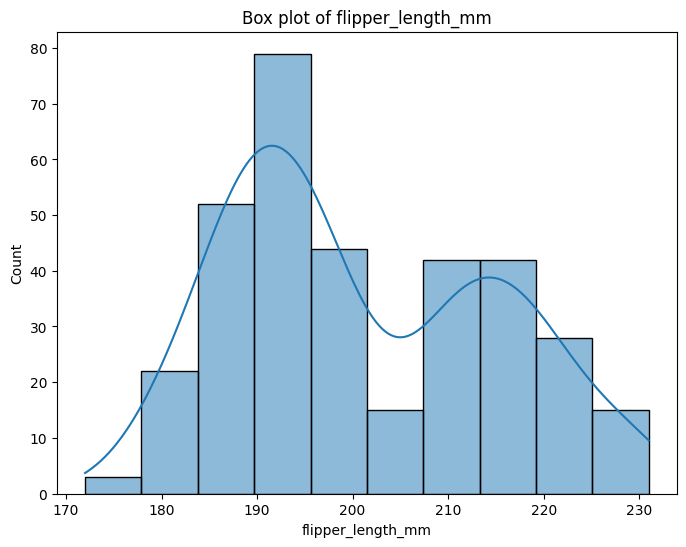

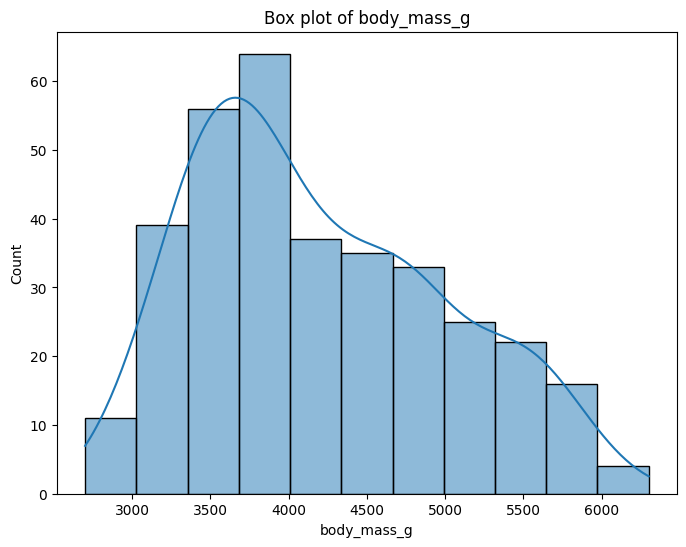

In [ ]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde=True)
  plt.title(f"Box plot of {col}")
  plt.show()

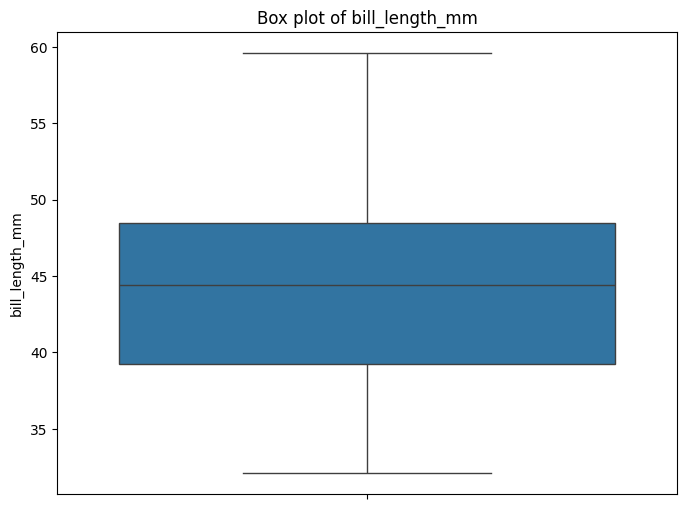

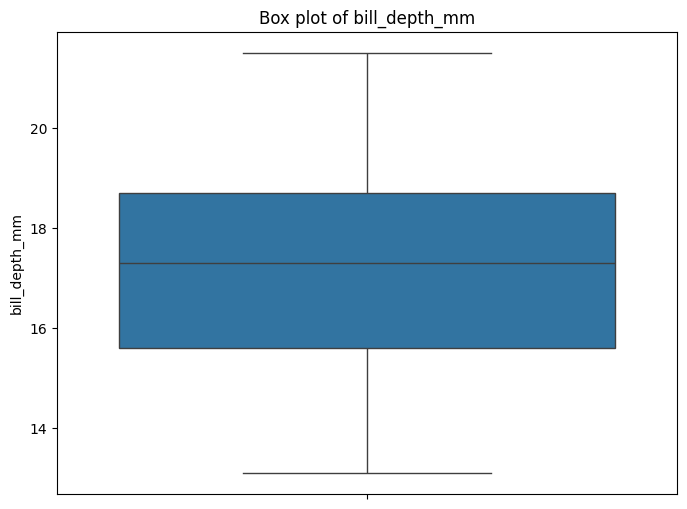

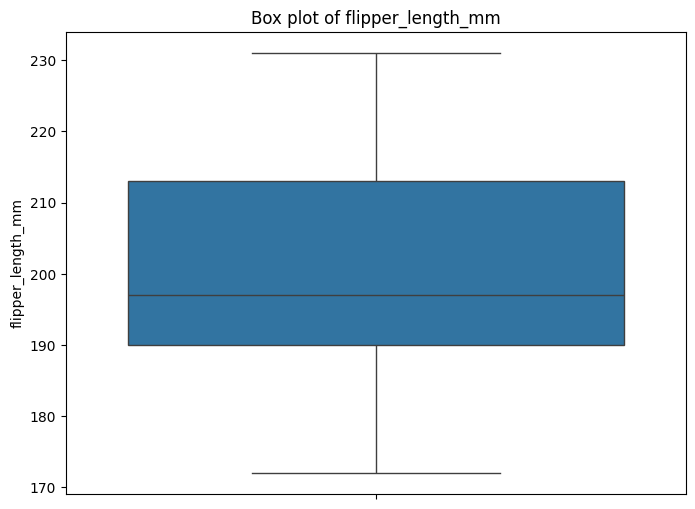

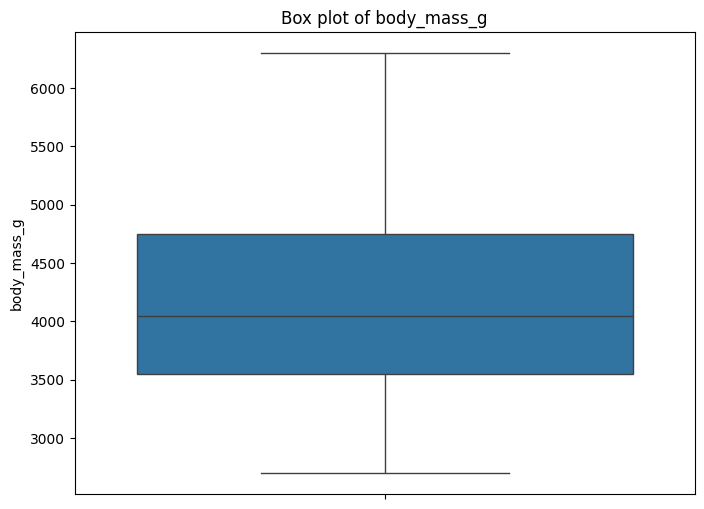

In [ ]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f"Box plot of {col}")
  plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['sex']=le.fit_transform(df['sex'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 21.4+ KB


In [ ]:
import pandas as pd

#One hot

df=pd.get_dummies(data=df,columns=['island'],prefix="island",drop_first=True)

In [ ]:
bol_cols=df.select_dtypes(include='bool').columns
df[bol_cols]=df[bol_cols].astype(int)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df['body_mass_g']=ss.fit_transform(df[['body_mass_g']])

df['flipper_length_mm']=ss.fit_transform(df[['flipper_length_mm']])

In [ ]:
le=LabelEncoder()
df['species']=le.fit_transform(df['species'])

In [ ]:
from sklearn.model_selection import train_test_split

y=df['body_mass_g']
x=df.drop(['body_mass_g'],axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=12)

In [ ]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(256, 7) (86, 7) (256,) (86,)


In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

regressor=MLPRegressor(hidden_layer_sizes=(64,),activation='relu',solver='adam',random_state=42,max_iter=1000,verbose=10,learning_rate='adaptive',
                       momentum=0.9)
regressor.fit(x_train,y_train)

Iteration 1, loss = 1.03043304
Iteration 2, loss = 0.93736832
Iteration 3, loss = 0.85318455
Iteration 4, loss = 0.77342412
Iteration 5, loss = 0.70031816
Iteration 6, loss = 0.63162002
Iteration 7, loss = 0.56548595
Iteration 8, loss = 0.50775619
Iteration 9, loss = 0.45496445
Iteration 10, loss = 0.40633739
Iteration 11, loss = 0.36155865
Iteration 12, loss = 0.32304015
Iteration 13, loss = 0.28779010
Iteration 14, loss = 0.25702930
Iteration 15, loss = 0.23047289
Iteration 16, loss = 0.20794036
Iteration 17, loss = 0.18766138
Iteration 18, loss = 0.17030481
Iteration 19, loss = 0.15652664
Iteration 20, loss = 0.14477109
Iteration 21, loss = 0.13531008
Iteration 22, loss = 0.12705482
Iteration 23, loss = 0.12110905
Iteration 24, loss = 0.11581911
Iteration 25, loss = 0.11214704
Iteration 26, loss = 0.10892897
Iteration 27, loss = 0.10630597
Iteration 28, loss = 0.10439681
Iteration 29, loss = 0.10263052
Iteration 30, loss = 0.10115825
Iteration 31, loss = 0.09983800
Iteration 32, los

MLPRegressor(hidden_layer_sizes=(64,), learning_rate='adaptive', max_iter=1000,
             random_state=42, verbose=10)

In [ ]:
predictions=regressor.predict(x_test)

mse=mean_squared_error(y_test,predictions)
rmse=np.sqrt(mse)
mae=mean_absolute_error(y_test,predictions)
r2=r2_score(y_test,predictions)

print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("Mean Absolute Error:",mae)
print("R2 score :",r2)

Mean Squared Error: 0.12764275313374115
Root Mean Squared Error: 0.3572712598764994
Mean Absolute Error: 0.2870670902464624
R2 score : 0.8666431142703167


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

model=Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(10,activation='relu'))

model.add(Dense(1))

In [ ]:
model.compile(optimizer='adam',loss='mae',metrics=['mae'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))

loss, mae=model.evaluate(x_test,y_test)

print("Test mae",mae)

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 1.1701 - mae: 1.1701 - val_loss: 1.1374 - val_mae: 1.1374
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.9860 - mae: 0.9860 - val_loss: 0.9774 - val_mae: 0.9774
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.8897 - mae: 0.8897 - val_loss: 0.8280 - val_mae: 0.8280
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7428 - mae: 0.7428 - val_loss: 0.6992 - val_mae: 0.6992
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.6964 - mae: 0.6964 - val_loss: 0.6021 - val_mae: 0.6021
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5488 - mae: 0.5488 - val_loss: 0.5375 - val_mae: 0.5375
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5623 - mae: 0.5623 - val_loss: 0.4843 - val_mae: 0.4843
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4677 - mae: 0.4677 - val_loss: 0.4485 - val_mae: 0.4485
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.45

In [ ]:
predictions=model.predict(x_test)
predictions_class=np.argmax(predictions,axis=1)
predictions_class

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

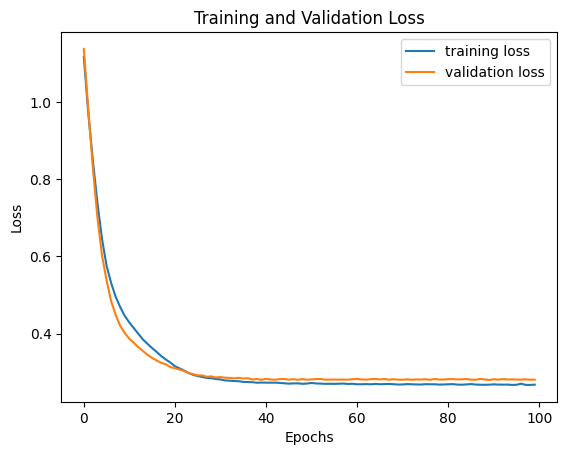

In [ ]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')

plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 10)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.08 KB)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 184 (740.00 B)

In [ ]:
#Diamonds


In [5]:
df=sns.load_dataset('diamonds')

In [6]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [7]:
df.isna().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [8]:
from scipy.stats import skew
cat_value=df.select_dtypes(include=["object"]).columns
num_value=df.select_dtypes(include=["int64","float64"]).columns

skew_value=df[num_value].skew()
skew_value

,0
carat,1.116646
depth,-0.082294
table,0.796896
price,1.618395
x,0.378676
y,2.434167
z,1.522423


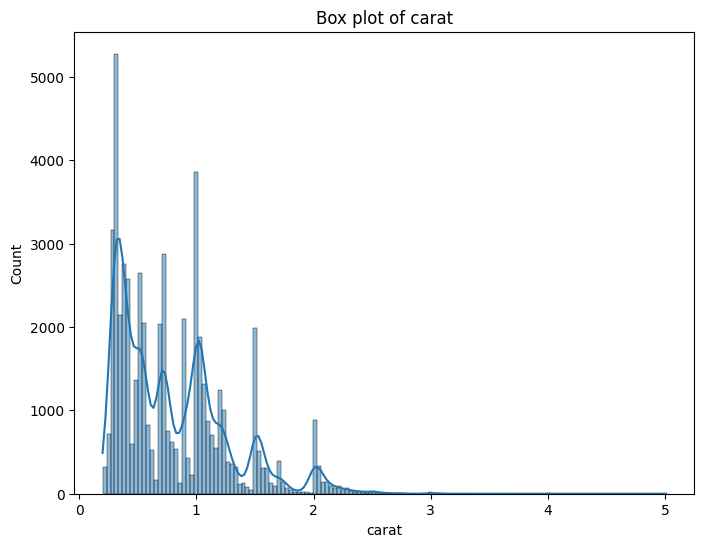

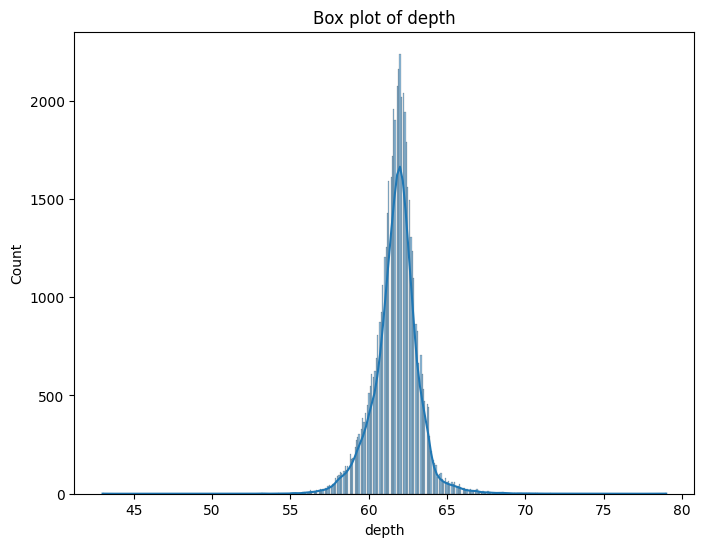

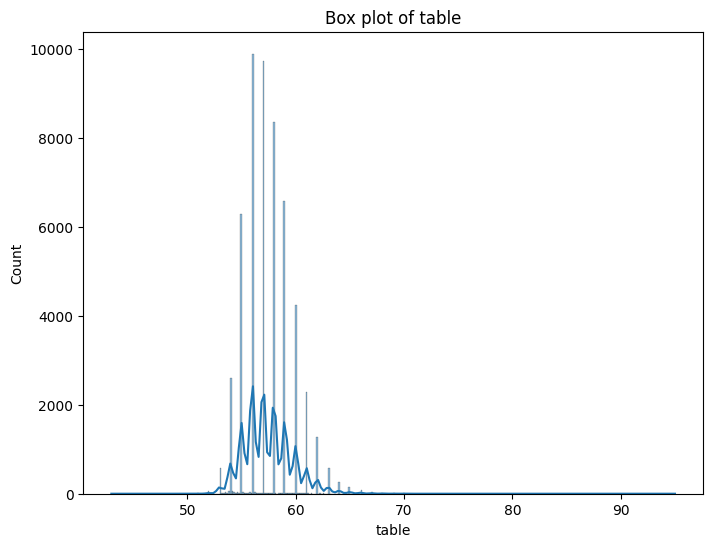

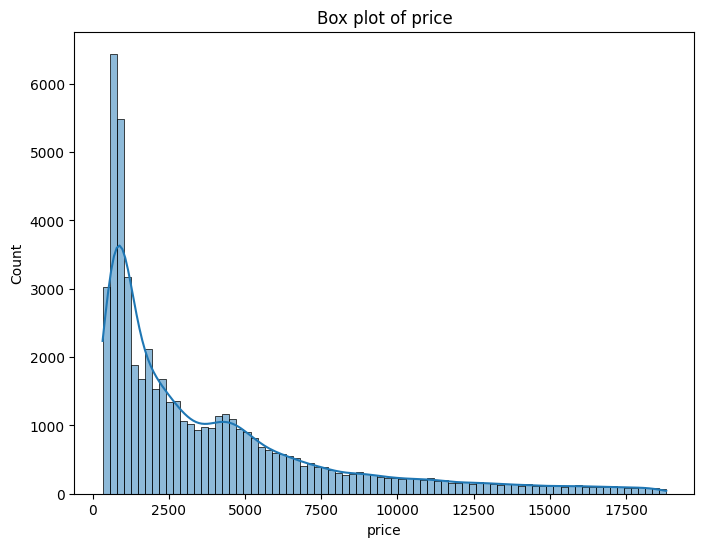

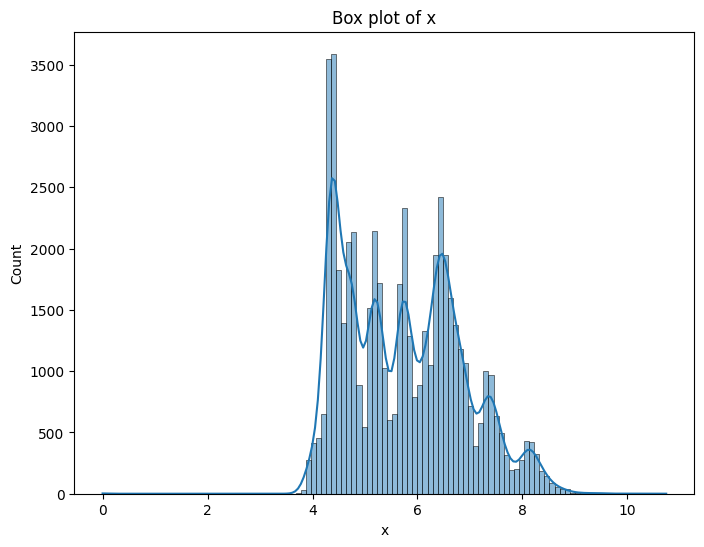

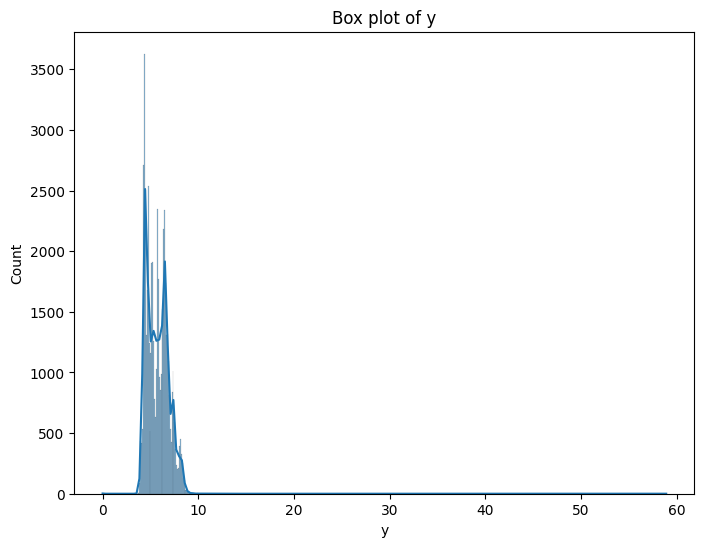

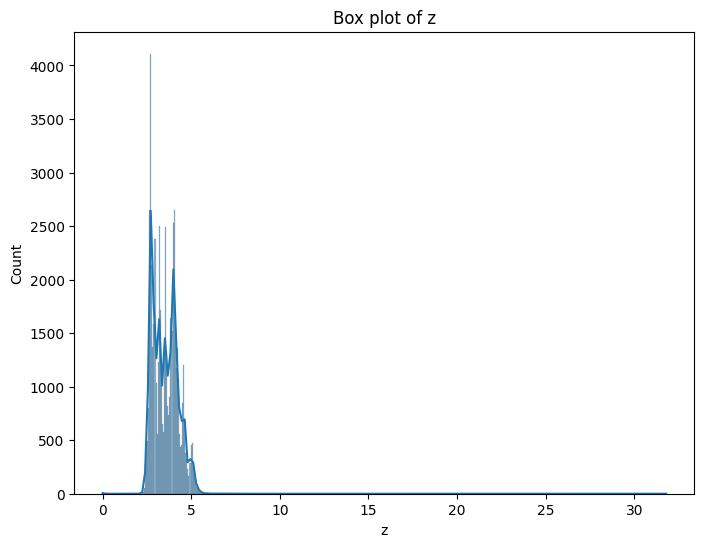

In [9]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde=True)
  plt.title(f"Box plot of {col}")
  plt.show()

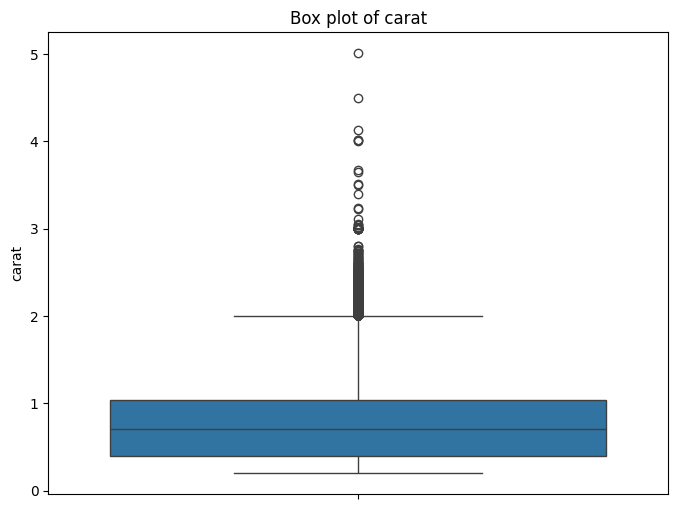

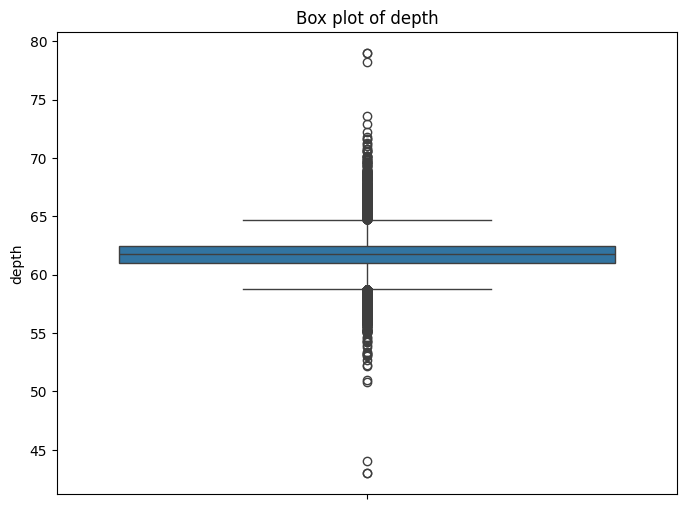

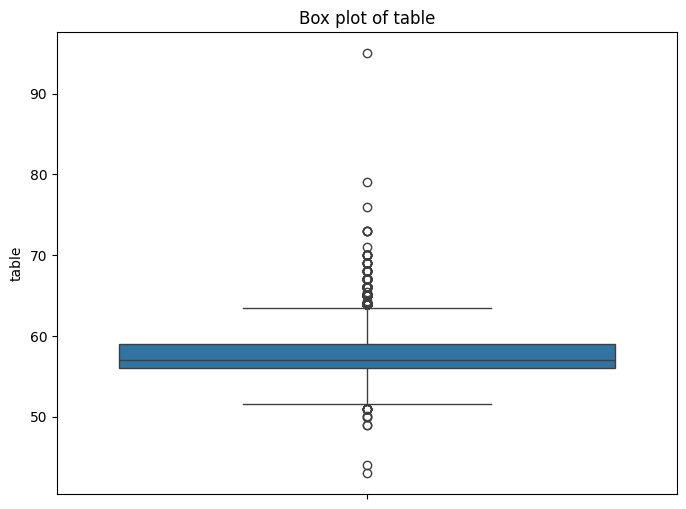

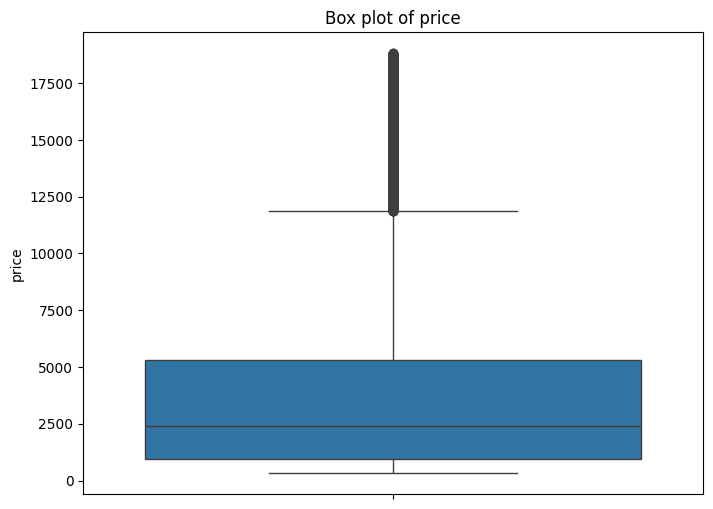

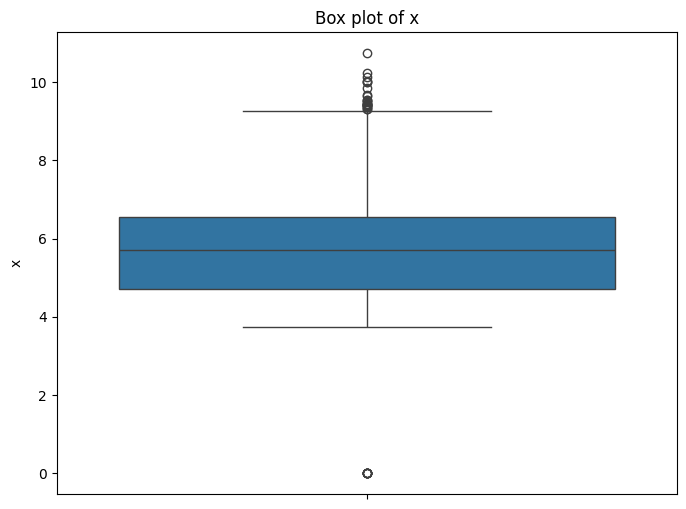

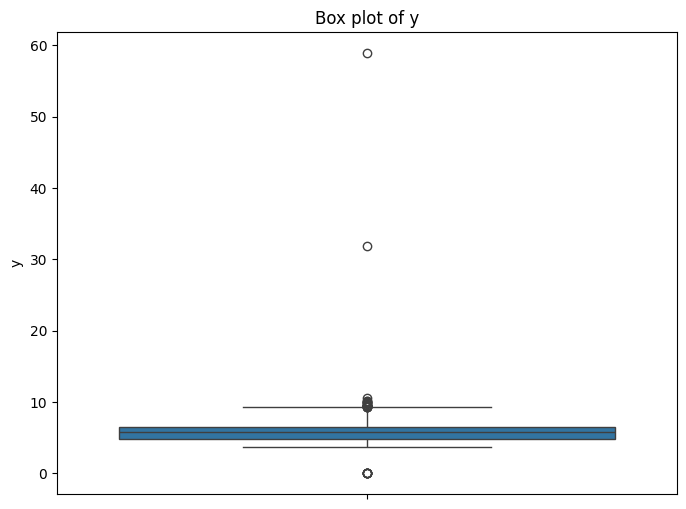

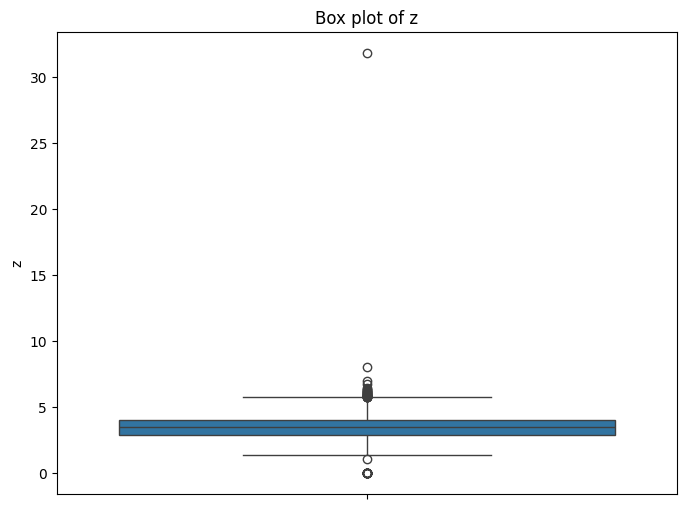

In [10]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f"Box plot of {col}")
  plt.show()

In [11]:
from scipy.stats.mstats import winsorize
for col in ['depth', 'table']:
  df[col] = winsorize(df[col], limits=(0.05, 0.05))



In [12]:
from sklearn.preprocessing import OrdinalEncoder
OrdinalEncoder()
df['cut']=OrdinalEncoder().fit_transform(df[['cut']]).astype(int)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,E,VS1,59.3,61.0,327,4.05,4.07,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [14]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['cut','color','clarity']]=oe.fit_transform(df[['cut','color','clarity']])
df.head()



,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2.0,1.0,3.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,1.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,1.0,4.0,59.3,61.0,327,4.05,4.07,2.31
3,0.29,3.0,5.0,5.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,6.0,3.0,63.3,58.0,335,4.34,4.35,2.75


In [17]:
columns=['carat','depth','table','x','y','z','price']
for col in columns:
  df[col]=np.log1p(df[col])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,2.0,1.0,3.0,4.135167,4.025352,5.789960,1.599388,1.605430,1.232560
1,0.190620,3.0,1.0,2.0,4.107590,4.127134,5.789960,1.587192,1.576915,1.196948
2,0.207014,1.0,1.0,4.0,4.099332,4.127134,5.793014,1.619388,1.623341,1.196948
3,0.254642,3.0,5.0,5.0,4.149464,4.077537,5.814131,1.648659,1.654411,1.289233
4,0.270027,1.0,6.0,3.0,4.163560,4.077537,5.817111,1.675226,1.677097,1.321756


In [18]:
X=df.drop(columns=['price'],axis=1)
y=df['price']

In [19]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [22]:
model=Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

In [23]:
model.compile(optimizer='adam',loss='mse',metrics=['mae','mse','r2_score'])

In [24]:
learned=model.fit(X_train,y_train,epochs=100,batch_size=32,verbose=1,validation_data=(X_test,y_test))


Epoch 1/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 8.2804 - mae: 1.7488 - mse: 8.2804 - r2_score: -7.1426 - val_loss: 0.0591 - val_mae: 0.1862 - val_mse: 0.0591 - val_r2_score: 0.9426
Epoch 2/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0702 - mae: 0.1808 - mse: 0.0702 - r2_score: 0.9320 - val_loss: 0.0429 - val_mae: 0.1588 - val_mse: 0.0429 - val_r2_score: 0.9583
Epoch 3/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0425 - mae: 0.1550 - mse: 0.0425 - r2_score: 0.9582 - val_loss: 0.0350 - val_mae: 0.1431 - val_mse: 0.0350 - val_r2_score: 0.9660
Epoch 4/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0375 - mae: 0.1466 - mse: 0.0375 - r2_score: 0.9632 - val_loss: 0.0338 - val_mae: 0.1418 - val_mse: 0.0338 - val_r2_score: 0.9672
Epoch 5/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0348 - mae: 0.1410 - mse: 0.0348 - r2_score: 0.9661 - val_loss: 0.0264 - val_mae: 0.1228 - val_mse: 0.0264 - val_r2_score: 0.9744
Epoch 6/100
1349/1349 ━━

In [25]:
loss,mae,mse,r2=model.evaluate(X_test,y_test,verbose=0)
print(loss)
print(mae)
print(mse)
print(r2)

0.009653252549469471
0.07100457698106766
0.009653252549469471
0.9906308054924011


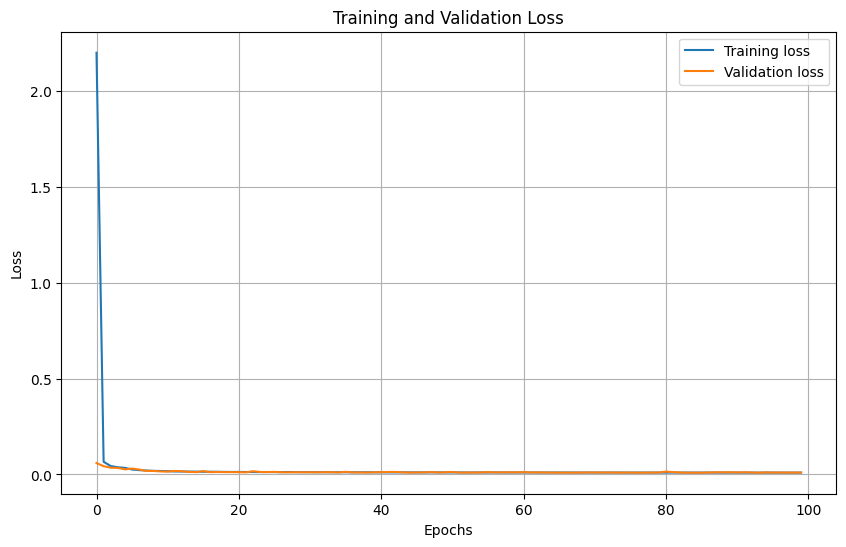

In [26]:
plt.figure(figsize=(10,6))
plt.plot(learned.history['loss'],label='Training loss')
plt.plot(learned.history['val_loss'],label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,797 (38.27 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,532 (25.52 KB)